# Notebook 06: Wilson-Dirac Operator

**Learning objectives:**
- Understand the Dirac gamma matrices and the Clifford algebra
- Build the Wilson-Dirac operator on a small lattice
- Visualize the sparsity pattern of $D_W$
- Understand the Wilson term and fermion doubling

**Prerequisites:** Notebooks 01-04

**Key functions:** `su2.gammas`, `su2.mass()`, `su2.initD()`

**From modular code:** `MesonBase.build_wilson_dirac_matrix()`, `MesonBase.generate_identity_gauge_field()`

In [1]:
from notebook_utils import setup_paths, load_config
REPO = setup_paths()

import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import su2

## 1. Dirac Gamma Matrices

The Dirac equation on the lattice requires four $4 \times 4$
gamma matrices satisfying the **Clifford algebra**:
$$\{\gamma_\mu, \gamma_\nu\} = 2 g_{\mu\nu} \mathbb{1}$$

In our (Dirac) representation:

In [2]:
print("Gamma matrices stored in su2.gammas:")
labels = ['gamma_0 (time)', 'gamma_1 (x)', 'gamma_2 (y)', 'gamma_3 (z)']
for i, label in enumerate(labels):
    print(f"\n{label}:")
    print(su2.gammas[i])

Gamma matrices stored in su2.gammas:

gamma_0 (time):
[[ 0.+0.j  0.+0.j  0.+0.j  0.+1.j]
 [ 0.+0.j  0.+0.j  0.+1.j  0.+0.j]
 [ 0.+0.j -0.-1.j  0.+0.j  0.+0.j]
 [-0.-1.j  0.+0.j  0.+0.j  0.+0.j]]

gamma_1 (x):
[[ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]]

gamma_2 (y):
[[ 0.+0.j  0.+0.j  0.+1.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -0.-1.j]
 [-0.-1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+1.j  0.+0.j  0.+0.j]]

gamma_3 (z):
[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [3]:
# Verify Clifford algebra: {gamma_mu, gamma_nu} = 2 * delta_mu_nu * I
for mu in range(4):
    for nu in range(mu, 4):
        anticomm = su2.gammas[mu] @ su2.gammas[nu] + su2.gammas[nu] @ su2.gammas[mu]
        if mu == nu:
            expected = 2 * np.eye(4)
            check = np.allclose(anticomm, expected)
            print(f"  {{gamma_{mu}, gamma_{nu}}} = 2*I : {check}")
        else:
            check = np.allclose(anticomm, np.zeros((4,4)))
            print(f"  {{gamma_{mu}, gamma_{nu}}} = 0   : {check}")

print("\nClifford algebra verified!")

  {gamma_0, gamma_0} = 2*I : True
  {gamma_0, gamma_1} = 0   : True
  {gamma_0, gamma_2} = 0   : True
  {gamma_0, gamma_3} = 0   : True
  {gamma_1, gamma_1} = 2*I : True
  {gamma_1, gamma_2} = 0   : True
  {gamma_1, gamma_3} = 0   : True
  {gamma_2, gamma_2} = 2*I : True
  {gamma_2, gamma_3} = 0   : True
  {gamma_3, gamma_3} = 2*I : True

Clifford algebra verified!


## 2. Gamma-5 and Chiral Structure

$\gamma_5 = i \gamma_0 \gamma_1 \gamma_2 \gamma_3$ is the chirality operator.
It anticommutes with all $\gamma_\mu$: $\{\gamma_5, \gamma_\mu\} = 0$.

In [ ]:
# In Euclidean space, gamma_5 = gamma_0 * gamma_1 * gamma_2 * gamma_3
# (no factor of i -- the 'i' in the Minkowski definition compensates for
# the metric signature, but our gammas already satisfy {g_mu, g_nu} = 2*delta)
gamma5 = su2.gammas[0] @ su2.gammas[1] @ su2.gammas[2] @ su2.gammas[3]
print("gamma_5 =")
print(np.real(gamma5).astype(int))

# gamma_5^2 = I
print(f"\ngamma_5^2 = I: {np.allclose(gamma5 @ gamma5, np.eye(4))}")

# Anticommutes with all gamma_mu
for mu in range(4):
    ac = gamma5 @ su2.gammas[mu] + su2.gammas[mu] @ gamma5
    print(f"  {{gamma_5, gamma_{mu}}} = 0: {np.allclose(ac, 0)}")

## 3. Building the Wilson-Dirac Matrix

The Wilson-Dirac operator on the lattice is:
$$D_W = (m + 4r)\mathbb{1} - \frac{1}{2}\sum_\mu
\bigl[(r - \gamma_\mu)\,U_\mu(x)\,\delta_{y,x+\hat\mu}
     + (r + \gamma_\mu)\,U_\mu^\dagger(x-\hat\mu)\,\delta_{y,x-\hat\mu}\bigr]$$

- Size: $(8V) \times (8V)$ where $8 = 2_{\rm color} \times 4_{\rm spin}$
- Sparse: only nearest-neighbor couplings
- The $4r$ shift (Wilson term) removes fermion doublers

In [5]:
from MesonBase import build_wilson_dirac_matrix, generate_identity_gauge_field

La = [4, 4, 4, 4]
V = su2.vol(La)

mass = 0.1
wilson_r = 0.5

# Build with identity gauge field (free field theory)
U_free, _ = generate_identity_gauge_field(La)
D = build_wilson_dirac_matrix(mass, La, wilson_r=wilson_r, U=U_free,
                              verbose=True)

In [6]:
print(f"\nDirac matrix properties:")
print(f"  Shape: {D.shape}")
print(f"  Non-zeros: {D.nnz}")
print(f"  Sparsity: {D.nnz / (D.shape[0]**2) * 100:.2f}%")
print(f"  Dtype: {D.dtype}")


Dirac matrix properties:
  Shape: (2048, 2048)
  Non-zeros: 34816
  Sparsity: 0.83%
  Dtype: complex128


## 4. Sparsity Pattern

The Dirac matrix connects each site only to its nearest neighbors.
This creates a banded structure visible in the sparsity plot.

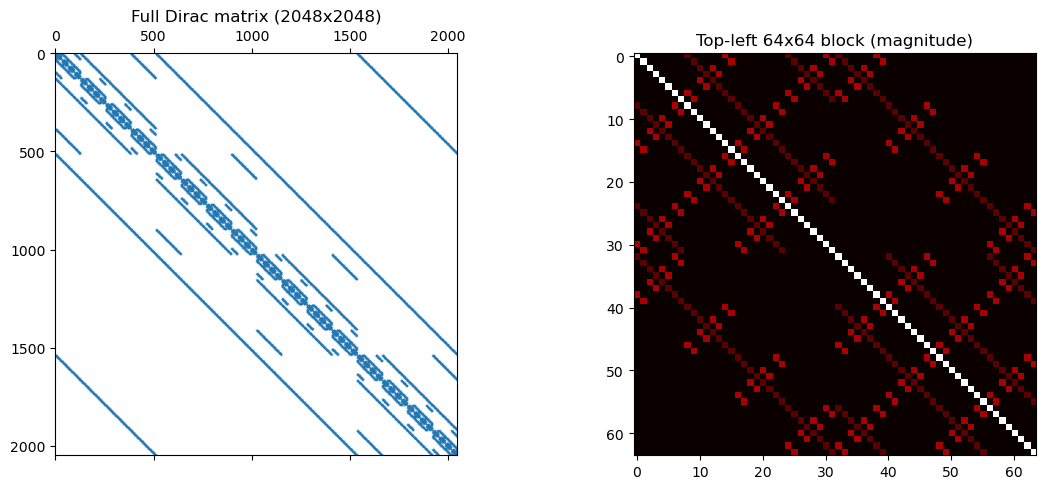

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full matrix sparsity
axes[0].spy(D, markersize=0.1)
axes[0].set_title(f'Full Dirac matrix ({D.shape[0]}x{D.shape[0]})')

# Zoom into top-left corner (first few sites)
n_show = min(64, D.shape[0])
D_dense = D[:n_show, :n_show].toarray()
axes[1].imshow(np.abs(D_dense), cmap='hot', interpolation='none')
axes[1].set_title(f'Top-left {n_show}x{n_show} block (magnitude)')

plt.tight_layout()
plt.show()

## 5. Effect of the Wilson Term

Without the Wilson term ($r=0$), naive lattice fermions produce
$2^4 = 16$ degenerate species ("doublers") instead of one.
The Wilson term adds a momentum-dependent mass that lifts the doublers
to heavy masses $\sim 2r/a$, leaving only one light fermion.

The effective mass becomes $m_{\rm eff} = m + 4r$, which is an
**additive mass renormalization** specific to Wilson fermions.

In [ ]:
# Compare eigenvalue spectra for different r values
# Use small lattice for direct diagonalization
La_small = [2, 2, 2, 2]  # tiny lattice for eigenvalues
U_small, _ = generate_identity_gauge_field(La_small)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, r in zip(axes, [0.0, 0.5, 1.0]):
    D_r = build_wilson_dirac_matrix(0.1, La_small, wilson_r=r, U=U_small)
    eigs = np.linalg.eigvals(D_r.toarray())
    ax.scatter(eigs.real, eigs.imag, s=5, alpha=0.6)
    ax.set_xlabel('Re(eigenvalue)')
    ax.set_ylabel('Im(eigenvalue)')
    ax.set_title(f'r = {r}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Dirac eigenvalue spectrum for different Wilson r', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

At $r = 0$ you can see eigenvalues clustering near the origin -- these
are the doublers. Increasing $r$ pushes them away, leaving one species.

## Exercises

1. For a $4^4$ lattice, what is the matrix size of $D_W$? How many
   non-zero entries does it have?
2. Verify that the diagonal of $D_W$ equals $m + 4r$ everywhere.
3. **Mass dependence**: Change the quark mass from 0.1 to 0.5 and
   rebuild $D_W$. Heavier quarks increase the diagonal — how does the
   eigenvalue spectrum shift?
4. **Wilson parameter**: Change `wilson_r` from 0.5 to 0.0 or 1.0 and
   examine the eigenvalue spectrum. At $r = 0$, fermion doublers
   reappear — how many near-zero eigenvalues do you see?
5. Build $D_W$ with a thermalized gauge field (from the sample configs).
   How does the sparsity pattern differ from the free-field case?
6. **Fermion doubling study**: On a $2^4$ lattice with the identity gauge
   field, build $D_W$ at $r = 0$ (naive fermions) and diagonalize.
   Count eigenvalues with $|\mathrm{Re}(\lambda)| < 0.5$ — these are
   the 16 doubler species. Now set $r = 1$ and repeat: how many
   near-zero eigenvalues remain? This demonstrates the Wilson mechanism.
7. **Condition number**: Compute $\kappa(D_W) = |\lambda_{\max}|/|\lambda_{\min}|$
   for quark masses $m = 0.5, 0.2, 0.1, 0.05$ on a $2^4$ lattice.
   Plot $\kappa$ vs $m$. As $m \to 0$ the condition number diverges —
   this is the origin of **critical slowing down** in lattice QCD solvers.